# 1 Importación de librerias

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir",
                "numpy", "pandas", "scikit-learn", "pycaret"], check=False)
print("Si se instalaron paquetes, reinicia el kernel.")

Si se instalaron paquetes, reinicia el kernel.


In [9]:
# Importamos las herramientas de MLOps y visualización de PyCaret
from pycaret.classification import tune_model, plot_model, save_model

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from pycaret.classification import setup, compare_models, predict_model

# 2 Cargado del dataset

In [3]:
import pandas as pd

ruta_csv = "../data/features.csv"

df = pd.read_csv(ruta_csv)
print("Dataset cargado correctamente")
print(df.head())

Dataset cargado correctamente
          0         1         2         3         4         5         6  \
0  0.017995  0.383825  0.021868  0.003189  0.000911  0.000228  0.000000   
1  0.001394  0.001394  0.000558  0.001952  0.000558  0.000000  0.000000   
2  0.006127  0.000219  0.000219  0.000875  0.000000  0.000219  0.000438   
3  0.000315  0.000473  0.001103  0.000158  0.000158  0.000788  0.000315   
4  0.001479  0.000296  0.000296  0.000296  0.000000  0.000000  0.000000   

          7         8        9  ...  247  248  249  250  251  252  253  254  \
0  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.000438  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.000788  0.000788  0.00063  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   255               label  
0  0.0  Apple__

# 3 División estratificada del dataset

In [4]:
X = df.drop('label', axis=1)
y = df['label']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # <--- Esto garantiza representación de las 38 clases
)


# 4 Configuración del setup para la comparación de modelos con AutoML

In [6]:
exp = setup(
    data=df,
    target='label',

    # rendimiento
    n_jobs=-1,
    fold=5,

    # preprocesamiento
    normalize=True,

    # PCA (bien usado aquí)
    pca=True,
    pca_components=0.95,

    # reproducibilidad
    session_id=123
)

,Description,Value
0,Session id,123
1,Target,label
2,Target type,Multiclass
3,Target mapping,"Apple___Apple_scab: 0, Apple___Black_rot: 1, Apple___Cedar_apple_rust: 2, Apple___healthy: 3, Background_without_leaves: 4, Blueberry___healthy: 5, Cherry___Powdery_mildew: 6, Cherry___healthy: 7, Corn___Cercospora_leaf_spot Gray_leaf_spot: 8, Corn___Common_rust: 9, Corn___Northern_Leaf_Blight: 10, Corn___healthy: 11, Grape___Black_rot: 12, Grape___Esca_(Black_Measles): 13, Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 14, Grape___healthy: 15, Orange___Haunglongbing_(Citrus_greening): 16, Peach___Bacterial_spot: 17, Peach___healthy: 18, Pepper,_bell___Bacterial_spot: 19, Pepper,_bell___healthy: 20, Potato___Early_blight: 21, Potato___Late_blight: 22, Potato___healthy: 23, Raspberry___healthy: 24, Soybean___healthy: 25, Squash___Powdery_mildew: 26, Strawberry___Leaf_scorch: 27, Strawberry___healthy: 28, Tomato___Bacterial_spot: 29, Tomato___Early_blight: 30, Tomato___Late_blight: 31, Tomato___Leaf_Mold: 32, Tomato___Septoria_leaf_spot: 33, Tomato___Spider_mites Two-spotted_spider_mite: 34, Tomato___Target_Spot: 35, Tomato___Tomato_Yellow_Leaf_Curl_Virus: 36, Tomato___Tomato_mosaic_virus: 37, Tomato___healthy: 38"
4,Original data shape,"(61486, 257)"
5,Transformed data shape,"(61486, 136)"
6,Transformed train set shape,"(43040, 136)"
7,Transformed test set shape,"(18446, 136)"
8,Numeric features,256
9,Preprocess,True


# 5 Selección del mejor modelo por medio de AutoML

In [ ]:

best_model = compare_models(include=['lr', 'lda', 'ridge', 'et', 'nb'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8662,0.9940,0.8662,0.8668,0.8634,0.8605,0.8607,3.2560
lr,Logistic Regression,0.8466,0.0000,0.8466,0.8462,0.8454,0.8403,0.8404,8.6480
lda,Linear Discriminant Analysis,0.5958,0.0000,0.5958,0.6390,0.5986,0.5806,0.5818,1.4680
ridge,Ridge Classifier,0.5620,0.0000,0.5620,0.5893,0.5182,0.5397,0.5432,1.1740
nb,Naive Bayes,0.4742,0.8681,0.4742,0.5520,0.4774,0.4569,0.4594,0.9520


# 6 Tuning del mejor modelo seleccionado por AutoML

In [ ]:

tuned_best = tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5710,0.9582,0.5710,0.6597,0.5614,0.5565,0.5594
1,0.5750,0.9584,0.5750,0.6638,0.5648,0.5605,0.5633
2,0.5839,0.9612,0.5839,0.6630,0.5735,0.5696,0.5723
3,0.5770,0.9595,0.5770,0.6696,0.5702,0.5625,0.5652
4,0.5742,0.9574,0.5742,0.6629,0.5653,0.5598,0.5628
Mean,0.5762,0.9589,0.5762,0.6638,0.5670,0.5618,0.5646
Std,0.0043,0.0013,0.0043,0.0032,0.0043,0.0044,0.0043


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


 El tuning redujo el rendimiento del modelo draticamente por lo tanto se opta por mantener el modelo son sus hiperparametros originales

# 7 Resultados, graficas y guardado del modelo

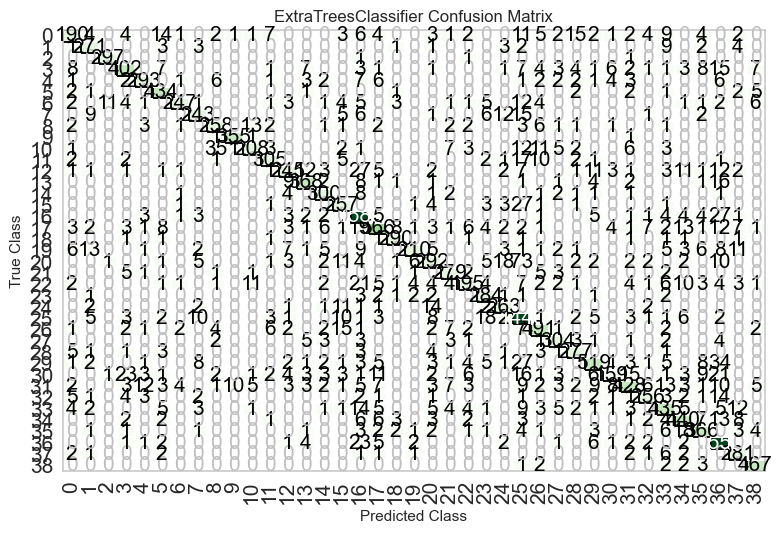

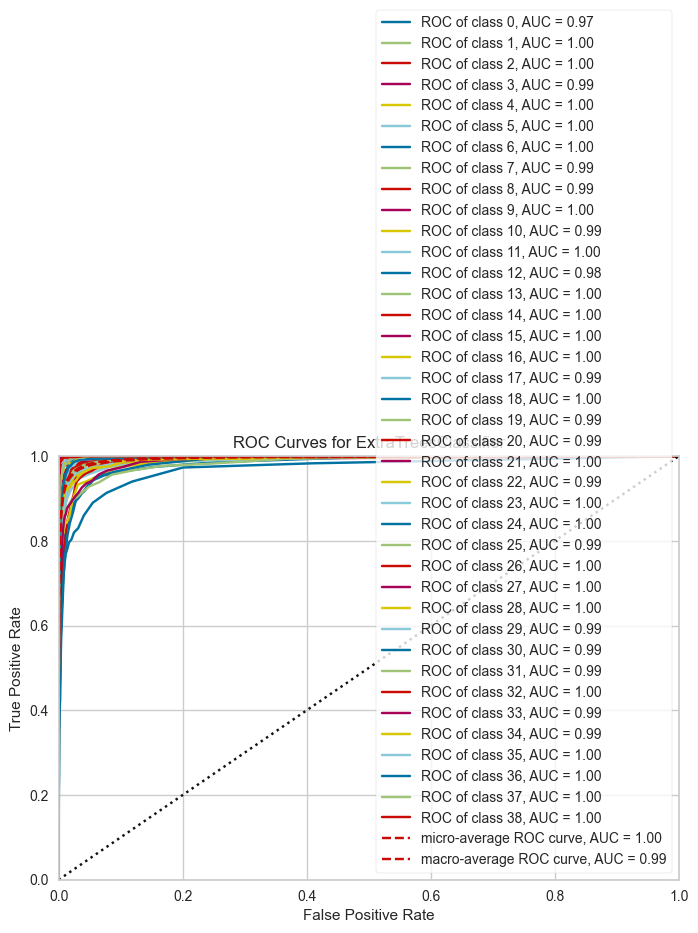

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['0', '1', '2', '3', '4', '5', '6',
                                              '7', '8', '9', '10', '11', '12',
                                              '13', '14', '15', '16', '17', '18',
                                              '19', '20', '21', '22', '23', '24',
                                              '25', '26', '27', '28', '29',...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                       class_weight=None, criterion='gini',
                                       max_depth=None, max_features='sqrt',
                                       max_leaf_nodes=

In [12]:
# 1. Generamos los gráficos directamente con el modelo original ganador
plot_model(best_model, plot='confusion_matrix')
plot_model(best_model, plot='auc')

# 2. Guardamos el pipeline con el Extra Trees original
save_model(best_model, 'modelo_plantvillage_et_final')

Tabla de desempeño del modelo

In [17]:
from pycaret.classification import predict_model, pull
predicciones = predict_model(tuned_best)


metricas_finales = pull()
print("Métricas Finales en Test:")
display(metricas_finales)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8702,0.9946,0.8702,0.8701,0.8673,0.8647,0.8649


Métricas Finales en Test:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8702,0.9946,0.8702,0.8701,0.8673,0.8647,0.8649


Tabla de aciertos realizados por el modelo

In [ ]:



predicciones = predict_model(best_model)


col_pred = 'prediction_label' if 'prediction_label' in predicciones.columns else 'Label'

total_real = predicciones['label'].value_counts().rename('Total_real')

aciertos = predicciones[predicciones['label'] == predicciones[col_pred]]['label'].value_counts().rename('Aciertos')
tabla_clases_test = pd.concat([total_real, aciertos], axis=1).fillna(0)
tabla_clases_test['Aciertos'] = tabla_clases_test['Aciertos'].astype(int)

tabla_clases_test['Recall'] = (tabla_clases_test['Aciertos'] / tabla_clases_test['Total_real']).round(4)
tabla_clases_test = tabla_clases_test.sort_values(by='Recall', ascending=False)

print("Desglose de Rendimiento por Clase (Conjunto de Prueba):")
display(tabla_clases_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8702,0.9946,0.8702,0.8701,0.8673,0.8647,0.8649


Desglose de Rendimiento por Clase (Conjunto de Prueba):


,Total_real,Aciertos,Recall
label,,,
Corn___Common_rust,358,355,0.9916
Apple___Cedar_apple_rust,300,297,0.9900
Tomato___healthy,477,467,0.9790
Peach___healthy,300,290,0.9667
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1607,1552,0.9658
Blueberry___healthy,451,434,0.9623
Orange___Haunglongbing_(Citrus_greening),1652,1585,0.9594
Potato___healthy,300,284,0.9467
Soybean___healthy,1527,1440,0.9430
